<h1><b>Modelo de Previsão para Séries Temporais</b><br>
<i>Previsão de demanda</i></h1>

## Componentes das Séries Temporais
Uma série temporal pode ser decomposta em:

- Tendência: direção de longo prazo
- Sazonalidade: repetição periódica de padrões
- Ruído: variação aleatória
<br>

<b>Importação das bibliotecas<br>
Estilizações para os Gráficos e<br>
Leitura dos dados</b>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns
#import statsmodels.tsa.stattools
from itertools import product
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#from statsmodels.stats.diagnostic import acorr_ljungbox
#from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss


plot_config= {
        "axes.facecolor": "#fff",     # Cor de fundo dos gráficos
        "axes.spines.top": False,     # Ativar ou remover borda superior
        "axes.spines.right": False,   # Ativar ou remover borda direita
        "axes.grid": False,           # Ativar ou remover grade
        "figure.figsize": (15, 6)     # Tamanho padrão da figura
}

plt.rcParams.update(plot_config)
sns.set_theme(rc= plot_config)


df = pd.read_csv("../../data/raw/demand.csv",
    usecols=['date', 'sales'],
    index_col="date",
    parse_dates=["date"]
)
df = df.resample('ME').sum(numeric_only=True)
df.head(2)

,sales
date,
2013-01-31,454904
2013-02-28,459417


<h3>Visualização da Série Temporal</h3>

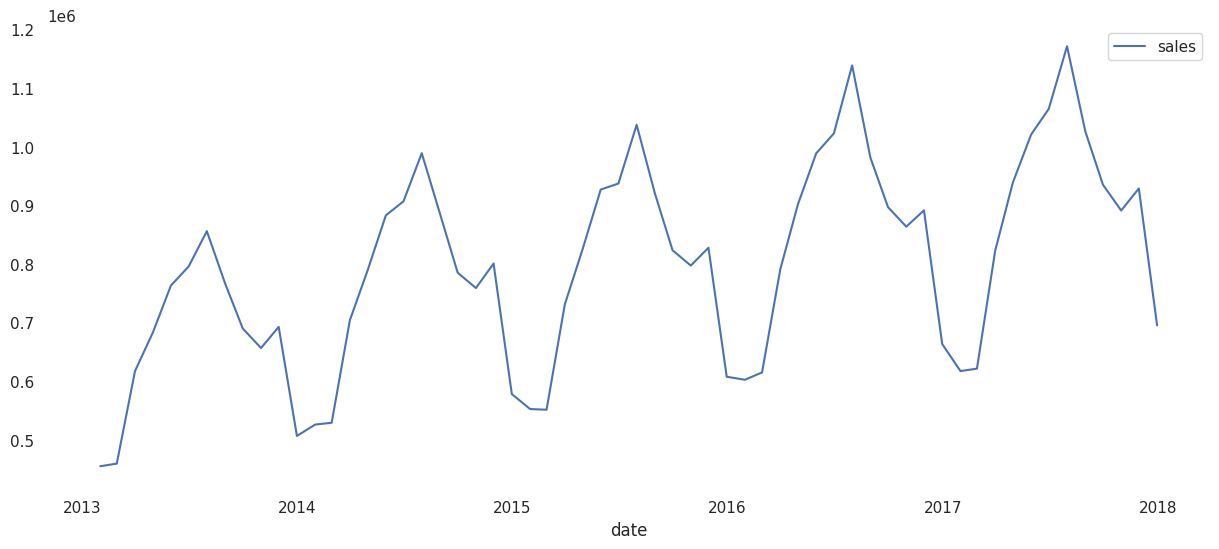

In [2]:
sns.lineplot(df);

### Estacionalidade

In [4]:
def test_stationarity(series, label='Série'):
    """Aplica ADF e KPSS e exibe resultado formatado."""
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')

    estac_adf  = 'Estacionária ✓' if adf_p < 0.05 else 'Não estacionária ✗'
    estac_kpss = 'Estacionária ✓' if kpss_p > 0.05 else 'Não estacionária ✗'

    print(f"\n{'='*55}")
    print(f" {label}")
    print(f"{'='*55}")
    print(f" ADF  → estatística: {adf_stat:8.4f}  p-valor: {adf_p:.4f}  → {estac_adf}")
    print(f" KPSS → estatística: {kpss_stat:8.4f}  p-valor: {kpss_p:.4f}  → {estac_kpss}")
    return adf_p < 0.05

# Nível original
is_stationary = test_stationarity(df['sales'], 'Série Original (nível)')

# 1ª diferença
df['sales_diff1'] = df['sales'].diff()
test_stationarity(df['sales_diff1'].dropna(), '1ª Diferença')

# 1ª diferença sazonal (lag=12)
df['sales_diff1_12'] = df['sales'].diff().diff(12)
test_stationarity(df['sales_diff1_12'].dropna(), '1ª Diferença + Diferença Sazonal (lag=12)')


 Série Original (nível)
 ADF  → estatística:  -5.2475  p-valor: 0.0000  → Estacionária ✓
 KPSS → estatística:   0.5360  p-valor: 0.0335  → Não estacionária ✗

 1ª Diferença
 ADF  → estatística:  -1.5290  p-valor: 0.5191  → Não estacionária ✗
 KPSS → estatística:   0.0777  p-valor: 0.1000  → Estacionária ✓

 1ª Diferença + Diferença Sazonal (lag=12)
 ADF  → estatística:  -6.5854  p-valor: 0.0000  → Estacionária ✓
 KPSS → estatística:   0.0605  p-valor: 0.1000  → Estacionária ✓


np.True_

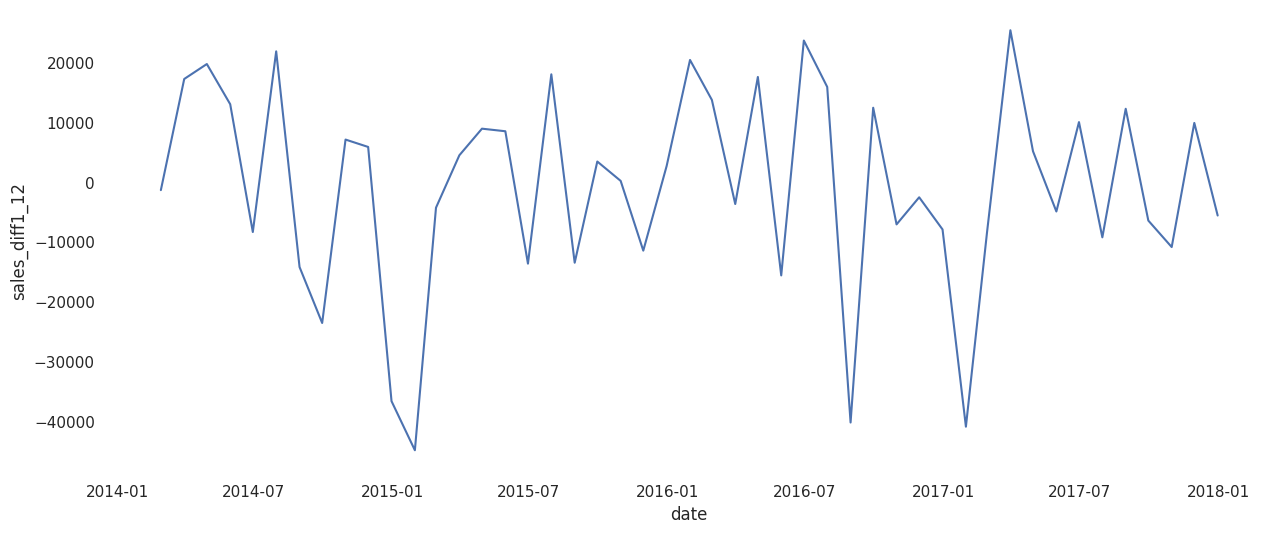

In [6]:
sns.lineplot(df['sales_diff1_12']);

### ACF e PACF para identificação de parâmetros

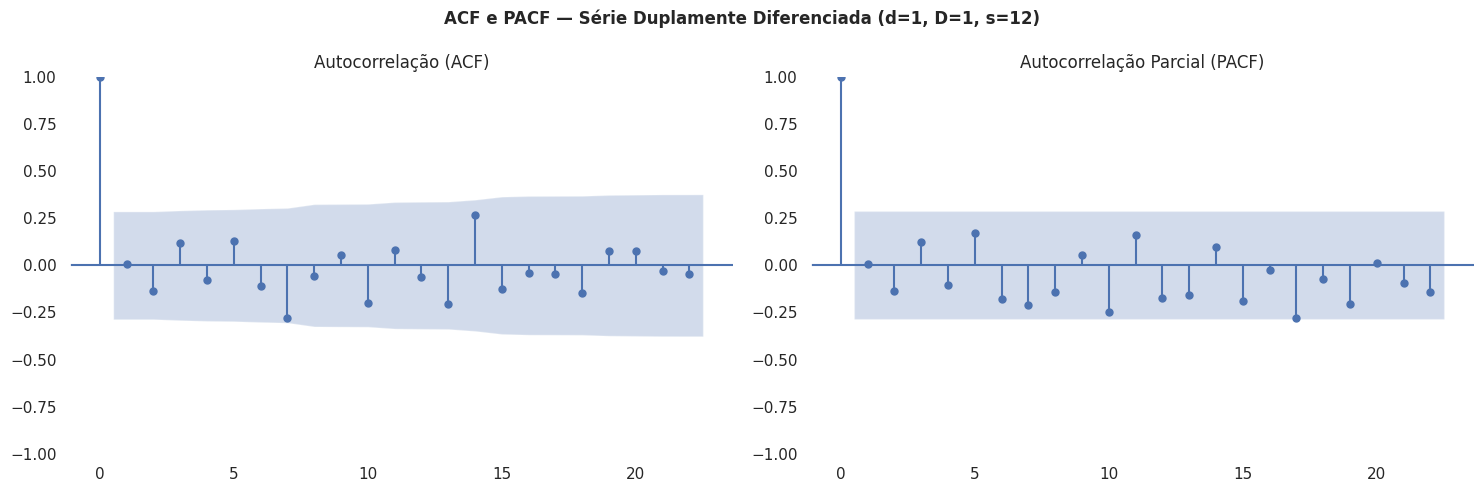

In [15]:
series_for_acf = df['sales_diff1_12'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACF e PACF — Série Duplamente Diferenciada (d=1, D=1, s=12)', fontsize=12, fontweight='bold')

plot_acf(series_for_acf,  ax=axes[0], lags=22, title='Autocorrelação (ACF)')
plot_pacf(series_for_acf, ax=axes[1], lags=22, method='ywm', title='Autocorrelação Parcial (PACF)')

plt.tight_layout()
plt.show()

## Grid Search de Hiperparâmetros SARIMA

In [17]:
# Espaço de busca — ajuste conforme necessidade e tempo disponível
# SARIMA(p,d,q)(P,D,Q)[s]
p_values = [0, 1, 2]
d_values = [1]          # d=1 indicado pelos testes
q_values = [0, 1, 2]
P_values = [0, 1, 2]
D_values = [1]          # D=1 para sazonalidade
Q_values = [0, 1, 2]
s = 12                  # sazonalidade anual

#train = df['sales']
train = df['sales_diff1_12'].dropna()

results = []
grid = list(product(p_values, d_values, q_values, P_values, D_values, Q_values))
total = len(grid)

print(f'Iniciando grid search: {total} combinações\n')

for i, (p, d, q, P, D, Q) in enumerate(grid):
    try:
        model = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False)
        results.append({
            'order': (p, d, q),
            'seasonal_order': (P, D, Q, s),
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2),
            'params': f'({p},{d},{q})({P},{D},{Q})[{s}]'
        })
    except Exception:
        pass

    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{total} combinações testadas...')

results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print(f'\nGrid search concluído! Top 10 modelos por AIC:\n')
print(results_df[['params', 'AIC', 'BIC']].head(10).to_string(index=False))

Iniciando grid search: 81 combinações

  10/81 combinações testadas...
  20/81 combinações testadas...
  30/81 combinações testadas...
  40/81 combinações testadas...
  50/81 combinações testadas...
  60/81 combinações testadas...
  70/81 combinações testadas...
  80/81 combinações testadas...

Grid search concluído! Top 10 modelos por AIC:

            params    AIC    BIC
(0,1,2)(0,1,2)[12] 168.71 168.44
(1,1,2)(0,1,2)[12] 170.09 169.77
(0,1,2)(1,1,2)[12] 170.57 170.25
(2,1,2)(0,1,2)[12] 171.12 170.74
(1,1,2)(1,1,2)[12] 172.08 171.70
(0,1,2)(2,1,2)[12] 172.56 172.18
(2,1,2)(1,1,2)[12] 173.07 172.63
(1,1,2)(2,1,2)[12] 173.95 173.52
(2,1,2)(2,1,2)[12] 175.06 174.58
(0,1,1)(0,1,2)[12] 188.71 189.02


### Validação Cruzada Temporal (Walk-Forward)

In [20]:
best = results_df.iloc[0]
best_order = best['order']
best_seasonal = best['seasonal_order']

def walk_forward_validation(series, order, seasonal_order, n_test=12, step=1):
    """
    Walk-forward (expanding window) validation.
    Treina o modelo em dados passados e prevê `step` passos à frente.
    Repete `n_test` vezes avançando um passo de cada vez.
    """
    n = len(series)
    n_train_start = n - n_test

    actuals, predictions, dates = [], [], []

    for i in range(n_test):
        train_slice = series.iloc[:n_train_start + i]
        test_val    = series.iloc[n_train_start + i]

        model = SARIMAX(
            train_slice,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False)
        pred = fit.forecast(steps=step).iloc[-1]

        actuals.append(test_val)
        predictions.append(pred)
        dates.append(series.index[n_train_start + i])

        print(f'  {series.index[n_train_start+i].strftime("%b/%Y")} | '
              f'Real: {test_val:>12,.0f} | '
              f'Previsto: {pred:>12,.0f} | '
              f'Erro: {abs(test_val - pred):>10,.0f}')

    return pd.DataFrame({'date': dates, 'actual': actuals, 'predicted': predictions}).set_index('date')


print(f'Walk-Forward Validation — SARIMA{best_order}{best_seasonal}')
print(f'{"─"*65}')
print(f'  Mês        | Real         | Previsto     | Erro abs')
print(f'{"─"*65}')

cv_results = walk_forward_validation(
    df['sales'],
    order=best_order,
    seasonal_order=best_seasonal,
    n_test=12
)
print(f'{"─"*65}')

Walk-Forward Validation — SARIMA(0, 1, 2)(0, 1, 2, 12)
─────────────────────────────────────────────────────────────────
  Mês        | Real         | Previsto     | Erro abs
─────────────────────────────────────────────────────────────────
  Jan/2017 | Real:      617,306 | Previsto:      597,242 | Erro:     20,064
  Feb/2017 | Real:      621,369 | Previsto:      622,675 | Erro:      1,306
  Mar/2017 | Real:      822,667 | Previsto:      802,766 | Erro:     19,901
  Apr/2017 | Real:      938,862 | Previsto:      914,099 | Erro:     24,763
  May/2017 | Real:    1,020,686 | Previsto:    1,012,092 | Erro:      8,594
  Jun/2017 | Real:    1,064,624 | Previsto:    1,043,059 | Erro:     21,565
  Jul/2017 | Real:    1,171,393 | Previsto:    1,167,790 | Erro:      3,603
  Aug/2017 | Real:    1,026,403 | Previsto:    1,028,787 | Erro:      2,384
  Sep/2017 | Real:      935,263 | Previsto:      926,701 | Erro:      8,562
  Oct/2017 | Real:      891,160 | Previsto:      896,444 | Erro:      5,284

### Modelo final e previsão

In [21]:
# Treinar modelo final com todos os dados
FORECAST_HORIZON = 12  # meses à frente

final_model = SARIMAX(
    df['sales'],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fit = final_model.fit(disp=False)

print(final_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   60
Model:             SARIMAX(0, 1, 2)x(0, 1, 2, 12)   Log Likelihood                -216.258
Date:                            Sat, 21 Mar 2026   AIC                            442.515
Time:                                    19:03:10   BIC                            447.494
Sample:                                01-31-2013   HQIC                           443.487
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0031      0.509     -1.970      0.049      -2.001      -0.005
ma.L2          0.3346      0.381   

### Avaliação

In [23]:
def evaluate(actual, predicted, label='Modelo'):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mape  = np.mean(np.abs((actual - predicted) / actual)) * 100
    smape = np.mean(2 * np.abs(actual - predicted) / (np.abs(actual) + np.abs(predicted))) * 100
    r2    = 1 - np.sum((actual - predicted)**2) / np.sum((actual - np.mean(actual))**2)
    return {'Modelo': label, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'sMAPE (%)': smape, 'R²': r2}

# Métricas Walk-Forward (out-of-sample)
metrics_cv = evaluate(cv_results['actual'], cv_results['predicted'], f'SARIMA{best_order}{best_seasonal} — CV')

# Métricas in-sample
metrics_is = evaluate(df['sales'], final_fit.fittedvalues, f'SARIMA{best_order}{best_seasonal} — In-sample')

# Naïve sazonal como baseline
naive_pred = df['sales'].shift(12).iloc[-12:]
metrics_naive = evaluate(cv_results['actual'], naive_pred.values, 'Naïve Sazonal (baseline)')

metrics_table = pd.DataFrame([metrics_naive, metrics_cv, metrics_is]).set_index('Modelo')
metrics_table['MAE']  = metrics_table['MAE'].map('{:,.0f}'.format)
metrics_table['RMSE'] = metrics_table['RMSE'].map('{:,.0f}'.format)
metrics_table['MAPE (%)']  = metrics_table['MAPE (%)'].map('{:.2f}%'.format)
metrics_table['sMAPE (%)'] = metrics_table['sMAPE (%)'].map('{:.2f}%'.format)
metrics_table['R²']   = metrics_table['R²'].map('{:.4f}'.format)

print('Comparação de Métricas\n')
print(metrics_table.to_string())

Comparação de Métricas

                                             MAE     RMSE MAPE (%) sMAPE (%)      R²
Modelo                                                                              
Naïve Sazonal (baseline)                  31,382   33,094    3.44%     3.50%  0.9614
SARIMA(0, 1, 2)(0, 1, 2, 12) — CV         10,780   13,429    1.26%     1.28%  0.9936
SARIMA(0, 1, 2)(0, 1, 2, 12) — In-sample  89,729  146,059   14.12%    14.67%  0.2743


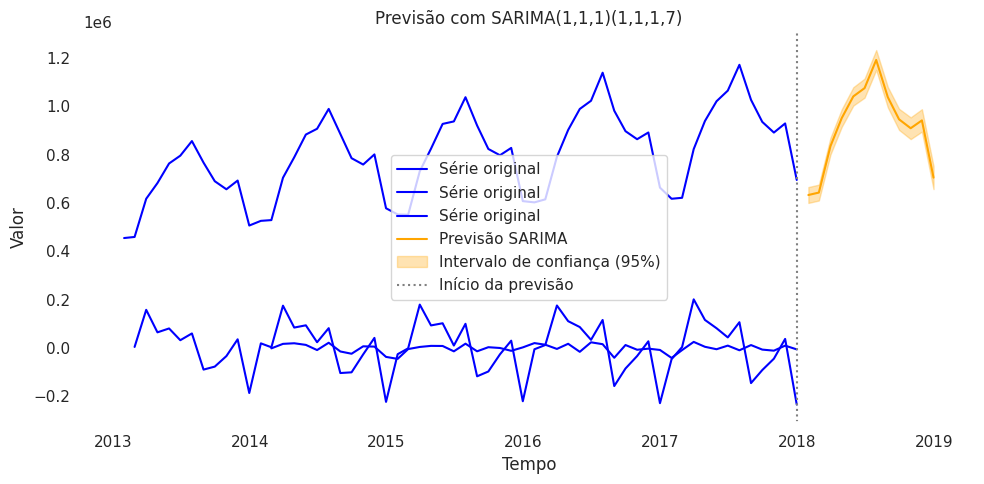

In [24]:
n_forecast = 12
forecast_res = final_fit.get_forecast(steps=n_forecast)

forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

forecast_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1),
                               periods=n_forecast, freq='ME')
forecast_mean.index = forecast_index
forecast_ci.index = forecast_index

plt.figure(figsize=(10,5))
plt.plot(df, label='Série original', color='blue')

plt.plot(forecast_mean, label='Previsão SARIMA', color='orange')

plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='orange', alpha=0.3, label='Intervalo de confiança (95%)')

plt.axvline(x=df.index[-1], color='gray', linestyle=':', label='Início da previsão')

plt.title('Previsão com SARIMA(1,1,1)(1,1,1,12)')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()